# Tabula Rasa experiments

Tabula Rasa is a JAX reference implementation for Monte Carlo estimation of Gaussian noise with unit variance and controlled spatial and temporal correlation. The renderer composes samplers, reconstruction filters, coordinate maps, procedural fields, and variance-correcting estimators.

This notebook provides focused experiments for visualizing sample distributions, validating variance correction and approximate unique counting, and inspecting correlation in procedural and multiresolution fields. Run the cells from top to bottom with the `tabula-rasa` kernel. The default `QUICK_RUN = True` setting keeps the experiments practical for interactive use; disable it only for the original research-scale workloads.


## Live module reloading

IPython's `autoreload` extension reloads imported Python modules before each cell executes. This lets edits under the local `tabula_rasa` package take effect without restarting the notebook kernel. The cell normally produces no visible output.


In [1]:
%load_ext autoreload
%autoreload 2


## Imports and workload controls

This cell imports JAX, plotting helpers, and the Tabula Rasa components used throughout the notebook. It also creates the shared `Renderer` instance.


In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial

from tabula_rasa import (
    BoxFilter,
    CountUniqueEstimator,
    Estimator,
    Field,
    HammersleySampler,
    Map,
    Renderer,
)
from tabula_rasa.field import hash_nd

renderer = Renderer()

QUICK_RUN = True  # Set False for the original, slower research-scale workloads.
LINEAR_COUNTING_BATCH_SIZE = 1_000 if QUICK_RUN else 100_000
COVARIANCE_REPETITIONS = 128 if QUICK_RUN else 10_000
COVARIANCE_SAMPLE_COUNT = 16 if QUICK_RUN else 20**2
MULTIRESOLUTION_TRIALS = 10_000 if QUICK_RUN else 1_000_000


## Visualize filtered Hammersley samples

This cell generates 216 low-discrepancy Hammersley samples for a single pixel. `Estimator.get_filter_samples` converts the sampler's unit-domain values into filtered sample positions and maps them into the field domain.

The scatter plot shows the <span style='color: #1f77b4'>sample positions (in blue)</span>; the larger point marks the <span style='color: #ff7f0e'>pixel center (in orange)</span>. An even, structured spread indicates that the Hammersley sequence is covering the pixel footprint as intended.


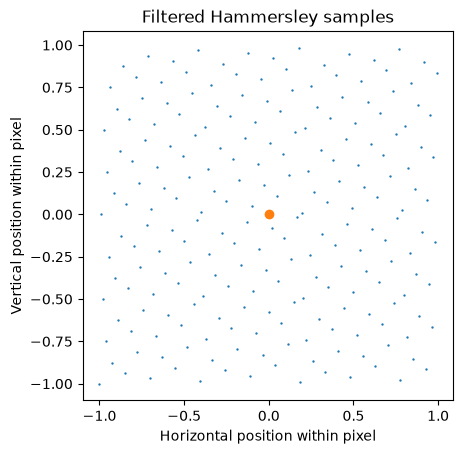

In [3]:
def test_samplers():
    resolution = (1, 1)
    coords = jnp.reshape(renderer.coord_grid(resolution), (-1, 2))
    keys = jax.random.split(jax.random.PRNGKey(0), coords.shape[0])
    sample_count = 216
    sampler = HammersleySampler(sample_count, sample_count)
    filter_obj = BoxFilter(resolution)
    map_obj = Map()

    def sample_pixel(position, sample_key):
        return Estimator.get_filter_samples(
            position, 0, sample_key, 0, sampler, filter_obj, map_obj
        )

    sample_coords = jax.vmap(sample_pixel)(coords, keys)["position"]
    sample_coords = jnp.reshape(sample_coords, (-1, 2))
    plt.scatter(*sample_coords.T, s=0.5)
    plt.scatter(*coords.T)
    plt.xlabel("Horizontal position within pixel")
    plt.ylabel("Vertical position within pixel")
    plt.title("Filtered Hammersley samples")
    plt.gca().set_aspect("equal")
    plt.show()


test_samplers()


## Verify weighted variance correction

Checks that <code>Estimator.variance_from_weights</code> rescales an unequally weighted average so its output retains unit variance.


In [4]:
# Configure three weighted variates and enough samples for a stable variance estimate.
variate_count = 3
sample_size = 100_000

# Normalize weights and compute the required standard-deviation correction.
weights = jnp.array([1, 1, 8], dtype=jnp.float32)
weights /= jnp.sum(weights)
stddev_correction = Estimator.variance_from_weights(weights)
print("Standard-deviation correction is " + str(stddev_correction))

# Generate independent corrected Gaussian variates and combine them with the weights.
samples = stddev_correction * jax.random.normal(
    jax.random.PRNGKey(1), (variate_count, sample_size)
)
y = jnp.sum(samples * weights[:, None], axis=0)

# The empirical variance should be close to 1.
print("Corrected variance is " + str(jnp.var(y)))


Standard-deviation correction is 1.230915
Corrected variance is 1.0009475


## Evaluate the linear-counting approximation

Compares exact distinct-value counts with a compact 256-bin linear-counting approximation over many random batches.


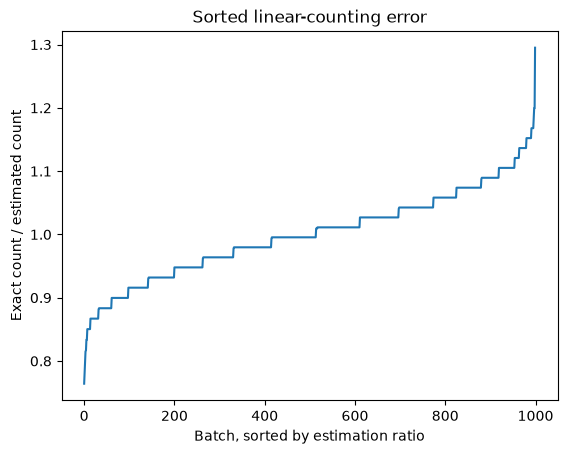

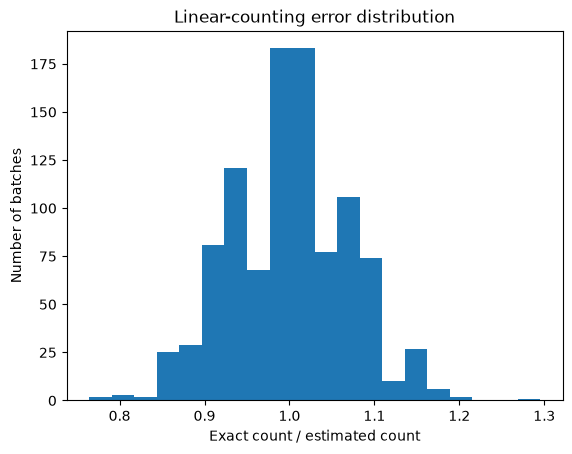

1st percentile of exact / estimated ratio: 0.85036886
99th percentile of exact / estimated ratio: 1.1521846


In [5]:
# Count unique values exactly to provide the reference result.
def gt(x):
    x = jnp.unique(x, size=1000, fill_value=-1)
    x = jnp.where(x == -1, 0, 1)
    return jnp.sum(x)


# Estimate the distinct count from the fraction of empty hash bins.
def linear_counting(x):
    bin_count = 2**8
    x = jnp.bitwise_and(x, bin_count - 1)
    mask = jnp.ones(bin_count)
    mask = mask.at[x].set(0)
    fraction = jnp.mean(mask)
    return -bin_count * jnp.log(fraction)


# Generate batches of 555 random 24-bit integers.
batch_size = LINEAR_COUNTING_BATCH_SIZE
x = jax.random.randint(
    jax.random.PRNGKey(1), (batch_size, 555), 0, 2**24 - 1
)

# Evaluate both counters across every batch; a ratio of 1 means exact agreement.
y_gt = jax.vmap(gt, in_axes=(0,))(x)
y_ours = jax.vmap(linear_counting, in_axes=(0,))(x)
ratio = y_gt / y_ours

# Sort the ratios to expose the lower and upper error tails.
plt.plot(jnp.sort(ratio))
plt.xlabel("Batch, sorted by estimation ratio")
plt.ylabel("Exact count / estimated count")
plt.title("Sorted linear-counting error")
plt.show()

# Show how tightly the estimates cluster around exact agreement.
plt.hist(ratio, bins=20)
plt.xlabel("Exact count / estimated count")
plt.ylabel("Number of batches")
plt.title("Linear-counting error distribution")
plt.show()

# Report the 1st and 99th percentile bounds of the observed ratios.
print("1st percentile of exact / estimated ratio:", jnp.percentile(ratio, 1))
print("99th percentile of exact / estimated ratio:", jnp.percentile(ratio, 99))


## Visualize spatial and temporal covariance

Renders a moving cyclic field repeatedly to compare correlations within one frame and across two different times.


Computing Counting


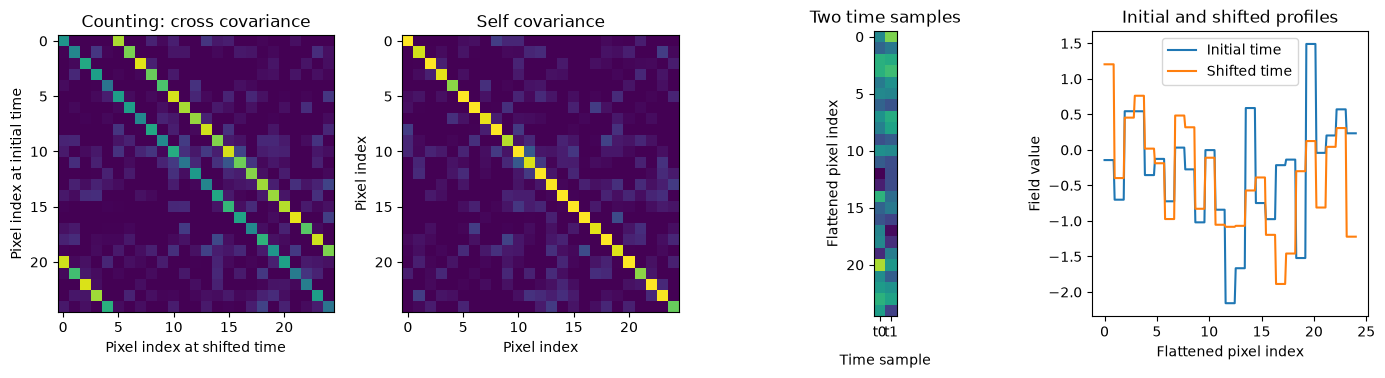

In [6]:
plt.rcParams["font.family"] = "DejaVu Sans"


# Move every sampled field position vertically as time advances.
class ShiftMap(Map):
    def __init__(self):
        self.range = 1

    def map(self, position, time, lens_coord):
        del lens_coord
        return {"position": position - jnp.array([0, time])}


# Wrap positions onto a repeating grid and hash each grid cell into a random value.
class CyclicField(Field):
    def position_to_key(self, position, footprint=None):
        del footprint
        # Convert the continuous [-1, 1] domain to integer grid coordinates.
        position = (position + 1) / 2
        position *= jnp.array(self.resolution)
        position = jnp.floor(position).astype(jnp.int32)
        # Wrap coordinates so moving past an edge repeats the field.
        position = (position + 100) % self.resolution
        return jnp.array([hash_nd(position)]), jnp.array([1])

    def position_to_value(self, position, footprint, value_key):
        # Turn the grid-cell key into one deterministic Gaussian field value.
        key = self.position_to_key(position, footprint)[0][0]
        value = self.key_to_value(key, value_key)
        return value, jnp.array([0], dtype=value.dtype)


# Render one estimator many times and measure relationships between its pixels.
def test_method(method, key, shape, times):
    estimator, map_obj, field, sampler, filter_obj = method
    estimate = partial(estimator.estimate, map_obj, field, sampler, filter_obj)

    # Produce one flattened 5 x 5 image for one time and random seed.
    def get_variate(time, key):
        sample_key, field_key = jax.random.split(key)
        accumulator = renderer.spread(
            estimate, shape, sample_key, 0, field_key, time
        )
        value = estimator.finish(accumulator)["value"]
        return jnp.reshape(value[..., 0], (-1,))

    # Compare every pixel in x with every pixel in y across repeated renders.
    def get_cross_covariance_matrix(x, y):
        x = x - jnp.mean(x, axis=0)
        y = y - jnp.mean(y, axis=0)
        products = x[..., :, None] * y[..., None, :]
        return jnp.mean(products, axis=0)

    # Reuse the same random seeds at both times so movement is the changed variable.
    keys = jax.random.split(key, COVARIANCE_REPETITIONS)
    render_repetitions = jax.jit(jax.vmap(get_variate, in_axes=(None, 0)))
    variate0 = render_repetitions(times[0], keys)
    variate1 = render_repetitions(times[1], keys)

    # Measure across-time covariance and same-time covariance separately.
    time_correlation = get_cross_covariance_matrix(variate0, variate1)
    self_correlation = get_cross_covariance_matrix(variate0, variate0)

    # Render one example at each time for a direct visual comparison.
    visualization_times = jnp.linspace(times[0], times[1], 2)
    visualization = jax.jit(jax.vmap(get_variate, in_axes=(0, None)))(
        visualization_times, key
    ).T
    return time_correlation, self_correlation, visualization


# Assemble a 5 x 5 counting-estimator pipeline for the cyclic field.
main_resolution = 5
shape = (main_resolution, main_resolution)
key = jax.random.PRNGKey(13)
map_obj = ShiftMap()
filter_obj = BoxFilter(shape)
field = CyclicField(main_resolution)
sampler = HammersleySampler(COVARIANCE_SAMPLE_COUNT, COVARIANCE_SAMPLE_COUNT)
methods = {
    "Counting": (
        CountUniqueEstimator(),
        map_obj,
        field,
        sampler,
        filter_obj,
    )
}

# Compare the starting field with the field after a 0.6-pixel vertical shift.
times = jnp.array([0, 0.6]) * 2 / main_resolution
results = []
for name, method in methods.items():
    print("Computing " + name)
    results.append(test_method(method, key, shape, times))

fig, axs = plt.subplots(
    len(results),
    4,
    figsize=(14, 4 * len(results)),
    gridspec_kw={"width_ratios": [1, 1, 1, 1]},
    squeeze=False,
)


def pplot(ax, values, label):
    expanded_values = jnp.repeat(values, 10, axis=0)
    expanded_positions = jnp.linspace(0, values.shape[0] - 1, expanded_values.shape[0])
    ax.plot(expanded_positions, expanded_values, label=label)


# Show cross-time covariance, same-time covariance, two images, and their traces.
for index, method_name in enumerate(methods):
    axs[index, 0].imshow(results[index][0], vmin=0, vmax=1)
    axs[index, 1].imshow(results[index][1], vmin=0, vmax=1)
    axs[index, 2].imshow(results[index][2], vmin=-2, vmax=2)
    pplot(axs[index, 3], results[index][-1][..., 0], "Initial time")
    pplot(axs[index, 3], results[index][-1][..., -1], "Shifted time")
    axs[index, 0].grid(False)
    axs[index, 1].grid(False)
    axs[index, 2].grid(False)
    axs[index, 0].set_title(f"{method_name}: cross covariance")
    axs[index, 0].set_xlabel("Pixel index at shifted time")
    axs[index, 0].set_ylabel("Pixel index at initial time")
    axs[index, 1].set_title("Self covariance")
    axs[index, 1].set_xlabel("Pixel index")
    axs[index, 1].set_ylabel("Pixel index")
    axs[index, 2].set_title("Two time samples")
    axs[index, 2].set_xlabel("Time sample", labelpad=10)
    axs[index, 2].set_ylabel("Flattened pixel index")
    axs[index, 2].set_xticks([0, 1], ["t0", "t1"])
    axs[index, 3].set_title("Initial and shifted profiles")
    axs[index, 3].set_xlabel("Flattened pixel index")
    axs[index, 3].set_ylabel("Field value")
    axs[index, 3].legend()
plt.tight_layout(pad=1.5)
plt.show()


## Combine explicit and procedural field values

Builds a field with two authored RGB pixels and deterministic procedural values everywhere else.


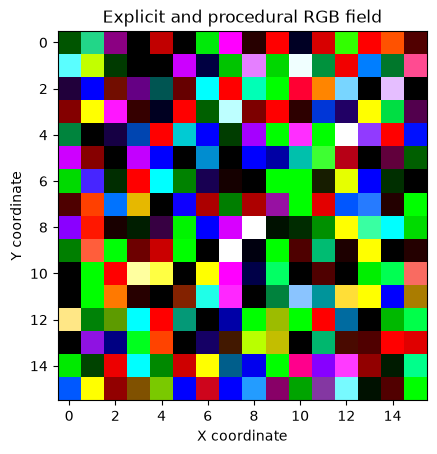

In [7]:
# Store explicit RGB values while retaining procedural fallback values.
class ExplicitField(Field):
    def __init__(self, resolution):
        super().__init__(resolution)
        self.value_dimension = 3

        # Assign red and green to two known coordinates.
        coordinates = jnp.array([[4, 4], [1, 10]])
        values = jnp.array([[1, 0, 0], [0, 1, 0]], dtype=jnp.float32)
        # Sort the hashed keys and their values together for binary search.
        keys = jax.vmap(hash_nd)(coordinates)
        indices = jnp.argsort(keys)
        self.hay_keys = keys[indices]
        self.hay_values = values[indices]

    # Search for an explicitly stored coordinate without indexing past the array.
    def known(self, position):
        needle_key = hash_nd(position)
        index = jnp.searchsorted(self.hay_keys, needle_key)
        safe_index = jnp.minimum(index, self.hay_keys.shape[0] - 1)
        is_known = (index < self.hay_keys.shape[0]) & (
            self.hay_keys[safe_index] == needle_key
        )
        return is_known, self.hay_values[safe_index]

    # Generate a repeatable random RGB value when the coordinate is not stored.
    def unknown(self, position, value_key):
        return self.key_to_value(hash_nd(position), value_key)

    # Select the explicit value when present, otherwise use the procedural value.
    def lookup(self, position, value_key):
        is_known, known_value = self.known(position)
        return jnp.where(is_known, known_value, self.unknown(position, value_key))

    # Adapt lookup to the value-and-mean interface expected by estimators.
    def position_to_value(self, position, footprint, value_key):
        del footprint
        value = self.lookup(position, value_key)
        return value, jnp.array([0], dtype=value.dtype)


# Evaluate the field at every coordinate in a 16 x 16 grid.
field = ExplicitField(16)
key = jax.random.PRNGKey(1)
x = jnp.arange(0, 16)
x = jnp.transpose(jnp.array(jnp.meshgrid(x, x)), (1, 2, 0))
y = jax.vmap(
    jax.vmap(field.lookup, in_axes=(0, None)), in_axes=(0, None)
)(x, key)

# Clip only the display copy because imshow expects floating-point RGB values in [0, 1].
display_y = jnp.clip(y, 0, 1)

# Display the authored pixels among the procedural RGB background.
plt.imshow(display_y)
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Explicit and procedural RGB field")
plt.show()


## Measure correlation in multiresolution noise

Combines coarse and fine 3D noise to show how shared coarse values create correlation between nearby positions.


Variance after independent-sample correction: 71.97914
Covariance matrix between final-axis positions:
[[2.9768112  1.9753369  0.97870916 0.9838159 ]
 [1.9753369  2.969879   0.9799289  0.9809603 ]
 [0.97870916 0.9799289  2.9912746  1.9935411 ]
 [0.9838159  0.9809603  1.9935411  3.0008526 ]]


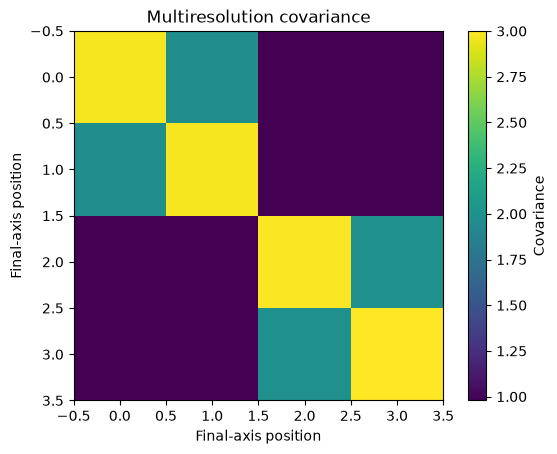

In [8]:
dimension = 3


# Build one 4 x 4 x 4 sample by adding coarse, medium, and fine noise grids.
def make_multiresolution_sample(key):
    level_count = 3
    keys = jax.random.split(key, level_count)
    levels = []

    for index in range(level_count):
        # Create independent noise at resolutions 1, 2, and 4 along each axis.
        resolution = 2**index
        level = jax.random.normal(keys[index], (resolution,) * dimension)
        # Repeat coarse values until every level has the same 4 x 4 x 4 shape.
        for axis in range(dimension):
            level = jnp.repeat(
                level, 2 ** (level_count - index - 1), axis=-(axis + 1)
            )
        levels.append(level)

    # Shared coarse values make neighboring output positions move together.
    return sum(levels)


# Generate many independent multiresolution fields for statistical measurement.
value_axes = tuple(range(-dimension, 0))
keys = jax.random.split(jax.random.PRNGKey(0), MULTIRESOLUTION_TRIALS)
level_samples = jax.vmap(make_multiresolution_sample)(keys)

# Give every voxel equal weight and compute the independent-sample variance factor.
weights = jnp.ones(level_samples[0].shape)
weights /= jnp.sum(weights, axis=value_axes)
variance = jnp.sum(weights**2)

# Average each field and apply the correction that would work for independent voxels.
combined_samples = jnp.sum(level_samples * weights, axis=value_axes)
combined_samples /= jnp.sqrt(variance)
print("Variance after independent-sample correction:", jnp.var(combined_samples, axis=0))

# Measure how each final-axis position varies with every other position.
def covariance(x):
    x = x - jnp.mean(x, axis=0)
    products = x[..., :, None] * x[..., None, :]
    return jnp.mean(products, axis=0)


# Pool the other dimensions, then print and visualize the 4 x 4 covariance matrix.
covariance_matrix = covariance(jnp.reshape(level_samples, (-1, 4)))
print("Covariance matrix between final-axis positions:")
print(covariance_matrix)
image = plt.imshow(covariance_matrix)
plt.xlabel("Final-axis position")
plt.ylabel("Final-axis position")
plt.title("Multiresolution covariance")
plt.colorbar(image, label="Covariance")
plt.show()


## Group values by key

Demonstrates how segment IDs group values with matching keys into a fixed-size summed output.


In [9]:
# Define the key attached to each value in this small example.
keys = jnp.array([0, 1, 2, 3, 4, 5])
values = jnp.array([1, 225435, 1, 22, 22, 3])


# Convert arbitrary keys to compact segment IDs, then sum values in each segment.
def key_segment_sum(values, keys):
    segments = jnp.unique(keys, size=10, return_inverse=True)[1]
    return jax.ops.segment_sum(values, segments, num_segments=10)


# Distinct input keys preserve the six values; unused output segments remain zero.
print("Segment sums:", key_segment_sum(values, keys))


Segment sums: [     1 225435      1     22     22      3      0      0      0      0]


In [10]:
# For larger studies, map the nested loops in bounded chunks and partially
# aggregate results to avoid unbounded host and device memory use.
